In [1]:
import torch
import torch.nn as nn
x = torch.rand(5, 3)
print(x)

tensor([[0.0369, 0.5647, 0.7534],
        [0.6530, 0.9069, 0.9774],
        [0.6565, 0.7810, 0.7668],
        [0.2477, 0.5144, 0.0219],
        [0.1796, 0.0485, 0.2019]])


In [69]:
print(torch.cuda.is_available())  
print(torch.cuda.get_device_name(0))
device = torch.device("cuda")
x = torch.randn(1, 3, dtype=float).to(device)
y = torch.randn(3, 1, dtype=float, device=device)
print(x.shape) 
print(x.dtype)
print(x)
print(y.shape) 
print(y.dtype)
print(y)

True
Tesla T4
torch.Size([1, 3])
torch.float64
tensor([[0.7126, 0.4502, 1.9026]], device='cuda:0', dtype=torch.float64)
torch.Size([3, 1])
torch.float64
tensor([[-0.8474],
        [-1.4968],
        [-1.5479]], device='cuda:0', dtype=torch.float64)


In [18]:
a = torch.randn(3, 3).to(device)
print(a.dtype)  # should be float32

# Explicit cast
b = a.to(torch.float16)
print(b.dtype)  # float16 - this is what LLMs run in
print(torch.cuda.memory_allocated() / 1024**2, "MB")

torch.float32
torch.float16
8.12939453125 MB


In [19]:
def multiply(a, b):
    return a @ b

print(multiply(x, y))

tensor([[1.5832]], device='cuda:0', dtype=torch.float64)


In [20]:
x = torch.randn(4, device='cuda')
y = torch.randn(4, device='cuda')
print(multiply(x, y))        # dot product - should be scalar
print(multiply(x, y).shape)  # what shape is it?

A = torch.randn(3, 4, device='cuda')
print(multiply(A, x))        # matrix-vector - should be shape (3,)
print(multiply(A, x).shape)

tensor(2.2288, device='cuda:0')
torch.Size([])
tensor([-1.6176,  0.1655,  0.2125], device='cuda:0')
torch.Size([3])


In [21]:
x = torch.tensor(4.0, requires_grad=True)
y = 3*x**2 + 2*x + 1

# what pytorch recorded - the last operation
print(y.grad_fn)

# one step back
print(y.grad_fn.next_functions)

# two steps back
print(y.grad_fn.next_functions[0][0].next_functions)

# three steps back
print(y.grad_fn.next_functions[0][0].next_functions[0][0].next_functions)

((<AddBackward0 object at 0x795f9219e4d0>, 0), (None, 0))
((<MulBackward0 object at 0x795f9219e4d0>, 0), (<MulBackward0 object at 0x795f91eba7a0>, 0))
((<PowBackward0 object at 0x795f91f24dc0>, 0), (None, 0))


In [ ]:
y = x * x
print(y.grad_fn.next_functions)
# Output: ((<AccumulateGrad object at ...>, 0), (<AccumulateGrad object at ...>, 0))

((<AccumulateGrad object at 0x7960c8239690>, 0), (<AccumulateGrad object at 0x7960c8239690>, 0))


In [66]:
X = torch.randn(100, 1, device='cuda')
y = 2 * X + 3 + 0.1 * torch.randn(100, 1, device='cuda')

slope_weight = torch.randn(1, device="cuda", requires_grad=True)
bias_weight = torch.randn(1, device="cuda", requires_grad=True)

for step in range(100):
    
    prediction_values = slope_weight * X + bias_weight
    mse = ((prediction_values - y)**2).mean()
    if mse.item() < 0.1:
        print(f"converged at step {step}")
        break
    mse.backward()
    # print(mse)
    learning_rate = 0.3
    with torch.no_grad():
        w1 = (slope_weight.grad)
        w2 = (bias_weight.grad)
        slope_weight -= learning_rate*w1
        bias_weight -= learning_rate*w2
        slope_weight.grad.zero_()
        bias_weight.grad.zero_()
    # print(w1)
    # print(w2)
print(mse)
print(slope_weight)
print(bias_weight)

converged at step 3
tensor(0.0774, device='cuda:0', grad_fn=<MeanBackward0>)
tensor([1.9678], device='cuda:0', requires_grad=True)
tensor([2.7571], device='cuda:0', requires_grad=True)


In [ ]:
X = torch.randn(100, 1, device='cuda')
y = 2 * X + 3 + 0.1 * torch.randn(100, 1, device='cuda')
linear_model = nn.Linear(1, 1, device="cuda")
learning_rate = 0.3
optimizer = torch.optim.SGD(params=linear_model.parameters(), lr=learning_rate)
for step in range(1000):
    loss = ((linear_model(X) - y)**2).mean()
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

print(f"Learned Slope (Weight): {linear_model.weight.item():.4f}")
print(f"Learned Intercept (Bias): {linear_model.bias.item():.4f}")

test_x = torch.tensor([[10.0]], device="cuda")
with torch.no_grad():
    prediction = linear_model(test_x)
    print(f"Prediction for x=10: {prediction.item():.4f}")

Learned Slope (Weight): 1.9901
Learned Intercept (Bias): 3.0072
Prediction for x=10: 22.9077


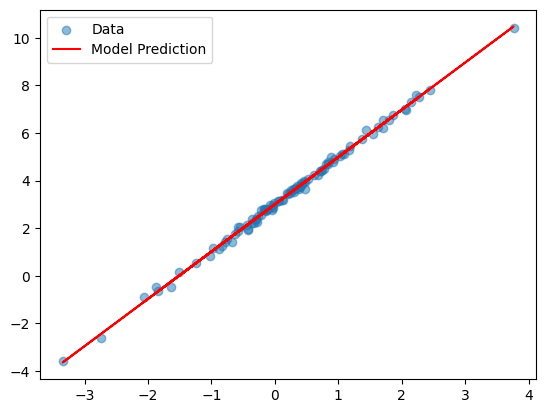

In [88]:
import matplotlib.pyplot as plt

# 1. Move to CPU and convert to NumPy
# .detach() is like saying "cut the umbilical cord to the graph"
X_cpu = X.cpu().numpy()
y_cpu = y.cpu().numpy()

with torch.no_grad():
    predictions_cpu = linear_model(X).cpu().numpy()

# 2. Plot the original "Noisy" dots
plt.scatter(X_cpu, y_cpu, label="Data", alpha=0.5)

# 3. Plot the "Learned" line
plt.plot(X_cpu, predictions_cpu, color='red', label="Model Prediction")
plt.legend()
plt.show()

In [90]:
import numpy as np

A = np.array([[1, 2],
              [3, 4]])

x1 = np.array([10, 20])          # shape (2,)
x2 = np.array([[10], [20]])      # shape (2,1)

out1 = A @ x1
out2 = A @ x2

print(out1, out1.shape)
print(out2, out2.shape)

[ 50 110] (2,)
[[ 50]
 [110]] (2, 1)


In [91]:
x1 = np.array([50, 110])       # shape (2,)
x2 = np.array([[50], [110]])   # shape (2,1)

print(x1[0])     # what do you get?
print(x2[0])     # what do you get?

50
[50]


In [28]:
tensorX = torch.randn(3, 2)
tensorY = torch.randn(2, 5)

vectorX = torch.randn(3)
vectorY = torch.randn(3)

batchX = torch.randn(6, 3, 2)
batchY = torch.randn(6, 2, 5)

queryM = torch.randn(5, 3, 5)
keyM = torch.randn(5, 3, 5)
#dot product
torch.einsum('i, i->', vectorX, vectorY)

#matrix multiply
torch.einsum('ij,jk->ik', tensorX, tensorY)

#batch matrix multiply
torch.einsum('bij, bjk -> bik', batchX, batchY)

#outer product
torch.einsum('i, j->ij', vectorX, vectorY)

#attention scores
torch.einsum('bij, bkj -> bik', queryM, keyM)

tensor([[[-0.0519, -1.4757, -0.1505],
         [ 2.0357, -2.4485, -3.3628],
         [-1.0146, -4.7306,  3.3222]],

        [[-2.4359,  2.9420,  1.1124],
         [ 1.3950, -1.3060,  0.2687],
         [-0.8111,  0.5613,  3.7599]],

        [[-4.9256, -1.4786, -3.2421],
         [ 4.0713,  2.4153,  2.9119],
         [-0.2356, -1.8127,  1.2683]],

        [[-0.8221,  0.6563, -2.2783],
         [-0.4570, -0.8625, -0.7482],
         [-0.3550, -0.7544, -0.1107]],

        [[ 0.6650, -0.9067,  0.7958],
         [-1.5105,  0.4595,  1.1988],
         [ 1.5960, -1.8339,  2.2658]]])